In [5]:
# CELL 0: Download metadata.csv directly from Kaggle using API Token
import os
from getpass import getpass

# 1. Ask for your Kaggle username and key
os.environ['KAGGLE_USERNAME'] = input("Enter your Kaggle username: ")
os.environ['KAGGLE_KEY'] = getpass("Enter your Kaggle API key (token): ")

# 2. Download ONLY the metadata.csv file from the dataset
print("\nDownloading metadata.csv from Kaggle (this might take a minute)...")
!kaggle datasets download -d allen-institute-for-ai/CORD-19-research-challenge -f metadata.csv

# 3. Unzip the downloaded file
!unzip -o metadata.csv.zip

print("Done! metadata.csv is now in your Colab environment.")

Enter your Kaggle username: mohamedaminehm
Enter your Kaggle API key (token): ··········

Dataset URL: https://www.kaggle.com/datasets/allen-institute-for-ai/CORD-19-research-challenge
License(s): other
100% 560M/560M [00:06<00:00, 89.9MB/s]

Archive:  metadata.csv.zip
  inflating: metadata.csv            
Done! metadata.csv is now in your Colab environment.


In [6]:
# CELL 1: Install required models and import libraries
!python -m spacy download en_core_web_sm -q

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') # Added to fix the LookupError

print("Libraries imported and models downloaded successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 83.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Libraries imported and models downloaded successfully!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [8]:
# CELL 2: Load and sample exactly 10,000 rows

# Load all columns first to show available options
df_full = pd.read_csv('metadata.csv', low_memory=False)
print("All available columns in metadata.csv:")
display(df_full.columns.tolist())
print("First 5 rows with all columns:")
display(df_full.head())

# Now, load only 'title' and 'abstract' to save RAM as originally intended
df = df_full[['title', 'abstract']].copy()

# Drop rows where the abstract is missing (NaN)
df = df.dropna(subset=['abstract'])

# Sample exactly 10,000 rows as required by the project
df = df.sample(n=10000, random_state=42).reset_index(drop=True)

print(f"Dataset shape after sampling: {df.shape}")
display(df.head())

All available columns in metadata.csv:


['cord_uid',
 'sha',
 'source_x',
 'title',
 'doi',
 'pmcid',
 'pubmed_id',
 'license',
 'abstract',
 'publish_time',
 'authors',
 'journal',
 'mag_id',
 'who_covidence_id',
 'arxiv_id',
 'pdf_json_files',
 'pmc_json_files',
 'url',
 's2_id']

First 5 rows with all columns:


,cord_uid,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,mag_id,who_covidence_id,arxiv_id,pdf_json_files,pmc_json_files,url,s2_id
0,ug7v899j,d1aafb70c066a2068b02786f8929fd9c900897fb,PMC,Clinical features of culture-proven Mycoplasma...,10.1186/1471-2334-1-6,PMC35282,11472636,no-cc,OBJECTIVE: This retrospective chart review des...,2001-07-04,"Madani, Tariq A; Al-Ghamdi, Aisha A",BMC Infect Dis,NaN,NaN,NaN,document_parses/pdf_json/d1aafb70c066a2068b027...,document_parses/pmc_json/PMC35282.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN
1,02tnwd4m,6b0567729c2143a66d737eb0a2f63f2dce2e5a7d,PMC,Nitric oxide: a pro-inflammatory mediator in l...,10.1186/rr14,PMC59543,11667967,no-cc,Inflammatory diseases of the respiratory tract...,2000-08-15,"Vliet, Albert van der; Eiserich, Jason P; Cros...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/6b0567729c2143a66d737...,document_parses/pmc_json/PMC59543.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
2,ejv2xln0,06ced00a5fc04215949aa72528f2eeaae1d58927,PMC,Surfactant protein-D and pulmonary host defense,10.1186/rr19,PMC59549,11667972,no-cc,Surfactant protein-D (SP-D) participates in th...,2000-08-25,"Crouch, Erika C",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/06ced00a5fc04215949aa...,document_parses/pmc_json/PMC59549.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
3,2b73a28n,348055649b6b8cf2b9a376498df9bf41f7123605,PMC,Role of endothelin-1 in lung disease,10.1186/rr44,PMC59574,11686871,no-cc,Endothelin-1 (ET-1) is a 21 amino acid peptide...,2001-02-22,"Fagan, Karen A; McMurtry, Ivan F; Rodman, David M",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/348055649b6b8cf2b9a37...,document_parses/pmc_json/PMC59574.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
4,9785vg6d,5f48792a5fa08bed9f56016f4981ae2ca6031b32,PMC,Gene expression in epithelial cells in respons...,10.1186/rr61,PMC59580,11686888,no-cc,Respiratory syncytial virus (RSV) and pneumoni...,2001-05-11,"Domachowske, Joseph B; Bonville, Cynthia A; Ro...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/5f48792a5fa08bed9f560...,document_parses/pmc_json/PMC59580.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN


Dataset shape after sampling: (10000, 2)


,title,abstract
0,Maternal and infant outcomes of full-term preg...,OBJECTIVE: To investigate the maternal and inf...
1,COVID-19: Characteristics and Therapeutics,Novel coronavirus (COVID-19 or 2019-nCoV or SA...
2,Multilingualism on the Berlin Stage: The Influ...,"This article analyses how language choice, lin..."
3,Psychometric properties of the French and Engl...,BACKGROUND: The Protective Behavioural Strateg...
4,Epidemiological changes of common respiratory ...,A variety of non‐pharmaceutical interventions ...


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


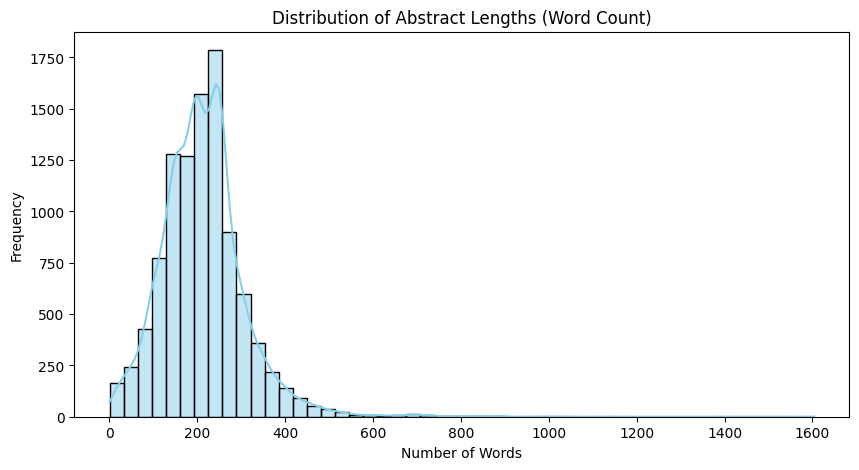

Calculating word frequencies...


/tmp/ipykernel_4549/3565263360.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='viridis')


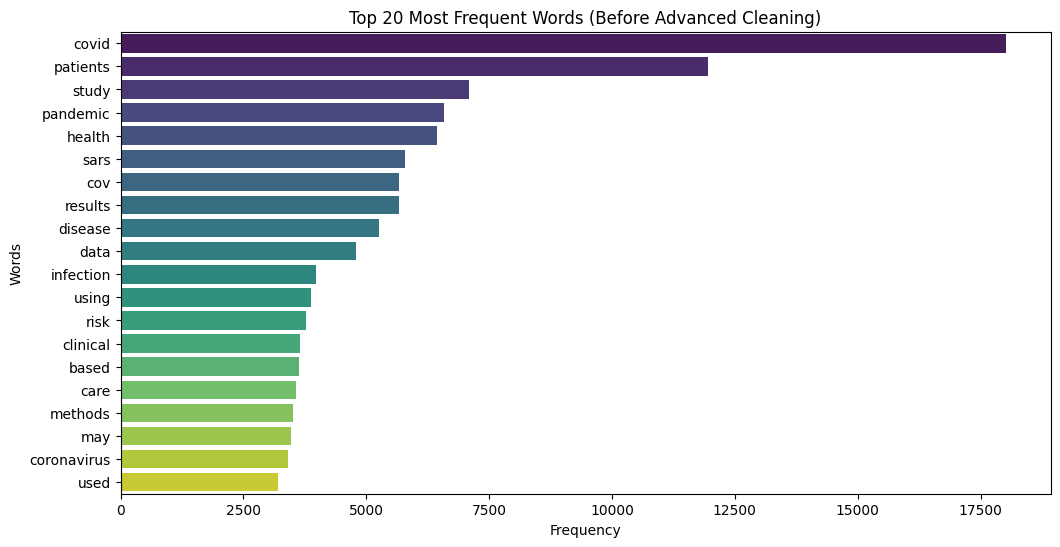

Generating WordCloud...


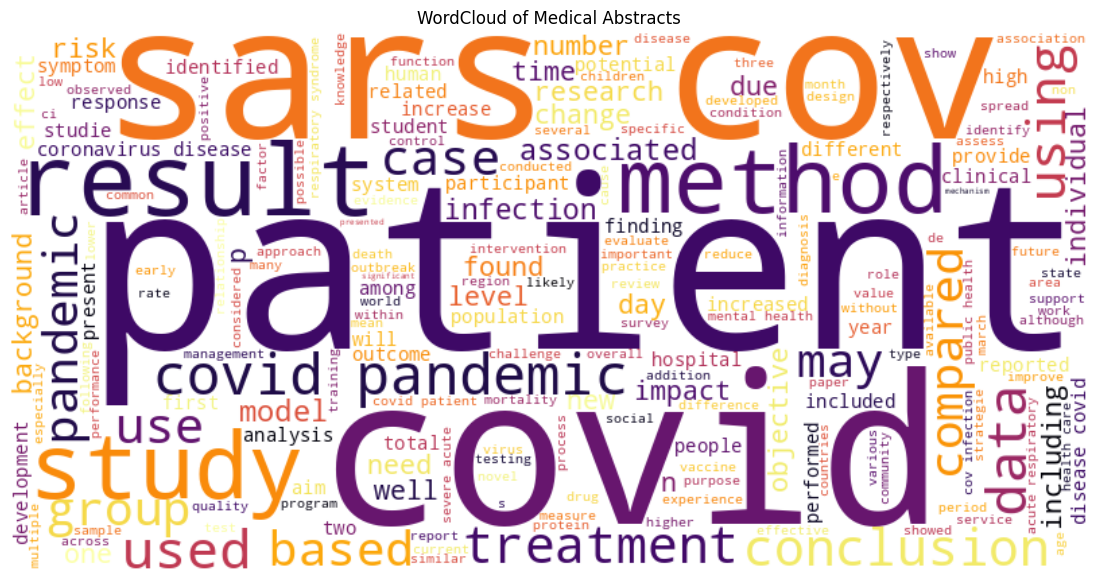

In [4]:
# CELL 3: EDA - Statistical Profiling & Initial Visualizations
import re
from collections import Counter
from nltk.corpus import stopwords

# 1. Statistical Profiling: Distribution of abstract lengths
df['abstract_length'] = df['abstract'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(df['abstract_length'], bins=50, color='skyblue', kde=True)
plt.title('Distribution of Abstract Lengths (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

# 2. Extract most frequent words for the Bar Plot
print("Calculating word frequencies...")
text_combined = " ".join(df['abstract'].astype(str).tolist()).lower()
raw_words = re.findall(r'\b[a-z]{3,}\b', text_combined) # Extract basic words

# Remove basic stop words just so the plot shows meaningful terms
basic_stops = set(stopwords.words('english'))
meaningful_words = [w for w in raw_words if w not in basic_stops]

word_counts = Counter(meaningful_words)
top_20_words = word_counts.most_common(20)
words, counts = zip(*top_20_words)

# 3. Bar Plot of most frequent words
plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(words), palette='viridis')
plt.title('Top 20 Most Frequent Words (Before Advanced Cleaning)')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

# 4. Initial Visualization: WordCloud
print("Generating WordCloud...")
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='inferno').generate(text_combined)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud of Medical Abstracts")
plt.show()

In [5]:
# CELL 4: NLTK Fine-grained cleaning and Academic Stop-word removal
import re
from nltk.tokenize import word_tokenize

# Define academic stopwords as requested in the project
academic_stopwords = {'study', 'results', 'significant', 'patient', 'patients', 'may', 'also', 'used', 'using', 'data', 'method', 'analysis', 'showed'}
stop_words = set(stopwords.words('english')).union(academic_stopwords)

def clean_with_nltk(text):
    text = str(text).lower()
    # Remove HTML tags and citations like [1] or (Smith, 2020)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\[\d+\]|\(\w+,\s\d{4}\)', ' ', text)
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and short words
    cleaned_tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return cleaned_tokens

print("Cleaning 10,000 abstracts with NLTK... (This takes about 15-30 seconds)")
df['nltk_tokens'] = df['abstract'].apply(clean_with_nltk)
df['cleaned_text'] = df['nltk_tokens'].apply(lambda x: " ".join(x))

print("NLTK Cleaning Complete! Here is a sample:")
print(df[['abstract', 'cleaned_text']].head(2))

Cleaning 10,000 abstracts with NLTK... (This takes about 15-30 seconds)
NLTK Cleaning Complete! Here is a sample:
                                            abstract  \
0  OBJECTIVE: To investigate the maternal and inf...   
1  Novel coronavirus (COVID-19 or 2019-nCoV or SA...   

                                        cleaned_text  
0  objective investigate maternal infant outcomes...  
1  novel coronavirus covid ncov sars cov suddenly...  


In [6]:
# CELL 5: spaCy Lemmatization, POS Tagging, and NER Visualization
import spacy
from spacy import displacy

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

print("Processing POS tagging and Lemmatization with spaCy... (Takes ~1 minute)")

# We use nlp.pipe for faster batch processing on 10,000 rows
spacy_processed = []
# Disable ner and parser here just to speed up the bulk lemmatization
for doc in nlp.pipe(df['abstract'].astype(str), batch_size=200, disable=['ner', 'parser']):
    # Isolate NOUN and ADJ (Symptoms/Descriptions) and Lemmatize
    lemmas = [token.lemma_.lower() for token in doc if token.pos_ in ['NOUN', 'ADJ'] and token.is_alpha]
    spacy_processed.append(" ".join(lemmas))

df['spacy_features'] = spacy_processed
print("spaCy Processing Complete!")

# NER (Named Entity Recognition) Visualization on a single abstract
print("\n--- Named Entity Recognition (NER) Demonstration ---")
sample_text = df['abstract'].iloc[0] # Take the first abstract
doc_ner = nlp(sample_text) # Process with full pipeline (including NER)

# Visualize the entities right in the notebook
displacy.render(doc_ner, style='ent', jupyter=True)

Processing POS tagging and Lemmatization with spaCy... (Takes ~1 minute)
spaCy Processing Complete!

--- Named Entity Recognition (NER) Demonstration ---


In [7]:
# Install gensim library
!pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 44.1 MB/s eta 0:00:00


In [8]:
# CELL 6: Gensim Word2Vec and LDA Topic Modeling
from gensim.models import Word2Vec
import gensim.corpora as corpora
from gensim.models import LdaModel

print("1. Training Word2Vec Model...")
# Train Word2Vec on our NLTK cleaned tokens
w2v_model = Word2Vec(sentences=df['nltk_tokens'], vector_size=100, window=5, min_count=5, workers=4)

# Test Semantic Mapping
word_to_test = 'virus'
print(f"\nWords most semantically similar to '{word_to_test}':")
if word_to_test in w2v_model.wv:
    for word, score in w2v_model.wv.most_similar(word_to_test, topn=5):
        print(f" - {word}: {score:.4f}")
else:
    print(f"'{word_to_test}' not found in vocabulary.")

print("\n--------------------------------------------------\n")

print("2. Training LDA Topic Model (Discovering hidden themes)...")
# Create Dictionary and Corpus for LDA
id2word = corpora.Dictionary(df['nltk_tokens'])
# Filter out words that occur in less than 10 documents or more than 50% of the documents
id2word.filter_extremes(no_below=10, no_above=0.5)
corpus = [id2word.doc2bow(text) for text in df['nltk_tokens']]

# Train LDA to find 5 hidden research themes
lda_model = LdaModel(corpus=corpus, id2word=id2word, num_topics=5, random_state=42, passes=3)

# Print the discovered themes
print("\nDiscovered Research Topics:")
for idx, topic in lda_model.print_topics(num_words=6):
    print(f"Topic {idx + 1}: {topic}")

1. Training Word2Vec Model...

Words most semantically similar to 'virus':
 - viruses: 0.8532
 - transmissible: 0.8372
 - pathogen: 0.8321
 - humans: 0.8158
 - pathogens: 0.8141

--------------------------------------------------

2. Training LDA Topic Model (Discovering hidden themes)...

Discovered Research Topics:
Topic 1: 0.008*"risk" + 0.007*"group" + 0.006*"clinical" + 0.006*"methods" + 0.006*"compared" + 0.006*"disease"
Topic 2: 0.010*"studies" + 0.009*"health" + 0.006*"review" + 0.006*"research" + 0.005*"pandemic" + 0.005*"vaccination"
Topic 3: 0.021*"sars" + 0.021*"cov" + 0.012*"infection" + 0.009*"disease" + 0.008*"cells" + 0.008*"respiratory"
Topic 4: 0.009*"model" + 0.007*"based" + 0.005*"cov" + 0.005*"virus" + 0.005*"sars" + 0.005*"different"
Topic 5: 0.014*"health" + 0.014*"pandemic" + 0.007*"care" + 0.007*"social" + 0.004*"students" + 0.004*"public"


1. Preparing Data for Modeling...

2. Training Classic ML Model (Random Forest)...
--- Random Forest Evaluation ---
Accuracy: 0.9880
F1-Score: 0.9846

3. Training Deep Learning Model with Early Stopping...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7451 - loss: 0.5112 - val_accuracy: 0.8238 - val_loss: 0.3774
Epoch 2/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8971 - loss: 0.2617 - val_accuracy: 0.8737 - val_loss: 0.2773
Epoch 3/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9508 - loss: 0.1424 - val_accuracy: 0.8950 - val_loss: 0.2485
Epoch 4/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9783 - loss: 0.0746 - val_accuracy: 0.9013 - val_loss: 0.2548
Epoch 5/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9900 - loss: 0.0367 - val_accuracy: 0.9137 - val_loss: 0.2501
Epoch 6/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9975 - loss: 0.0166 - val_accuracy: 0.9175 - val_loss: 0.2497
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

--- Deep Learning Evaluation ---
Accuracy: 0.8965
F1-Score: 0.8606

4. Plotting Learning Curves & Confusion 

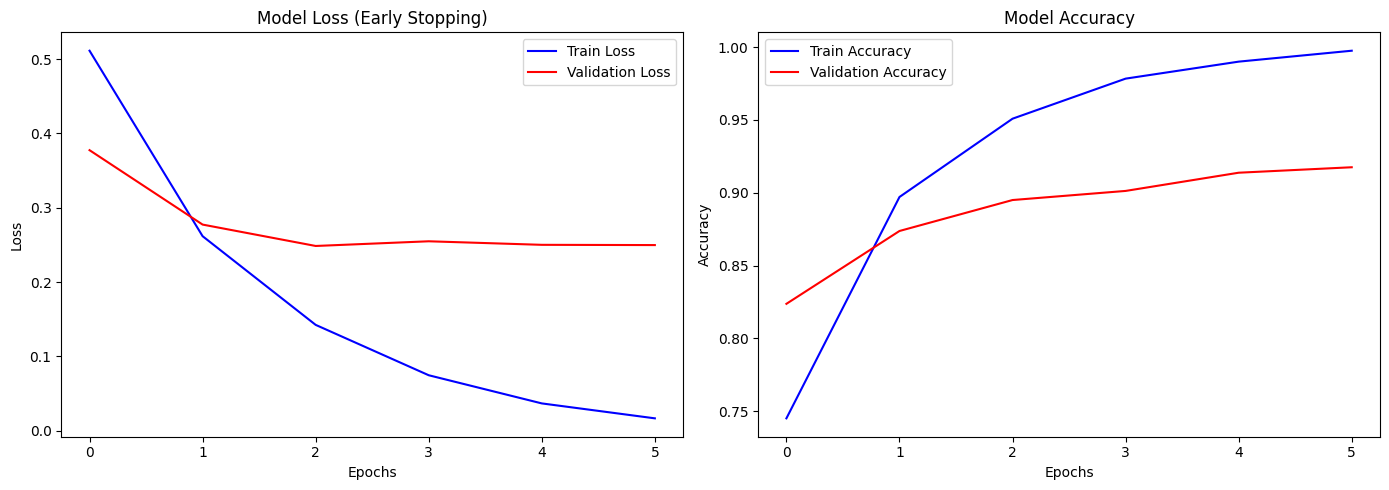

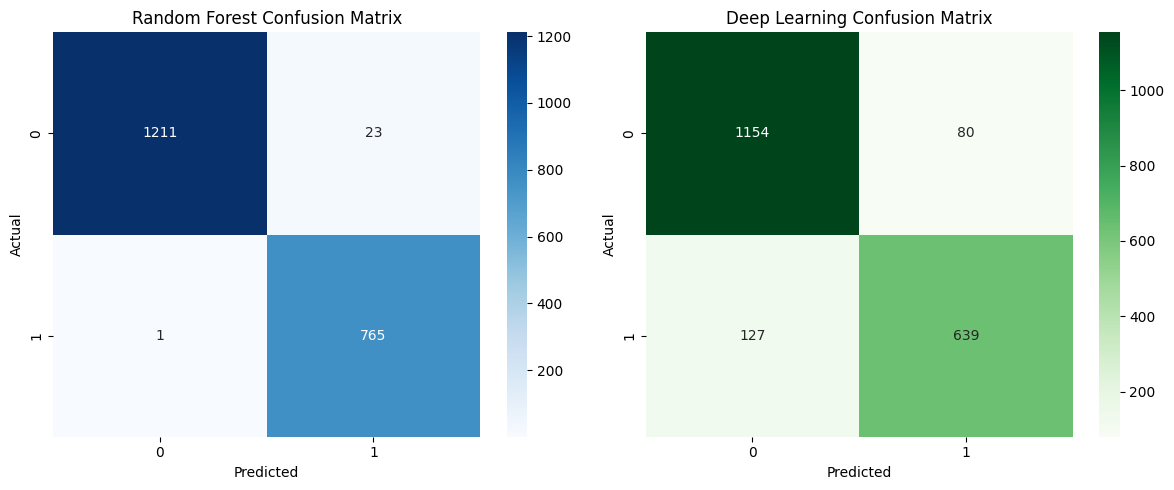

In [9]:
# CELL 7 (UPDATED): Classic ML, Deep Learning with Early Stopping & Learning Curves
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("1. Preparing Data for Modeling...")
keywords = {'vaccine', 'treatment', 'drug', 'therapy', 'trial', 'clinical'}
df['target'] = df['nltk_tokens'].apply(lambda x: 1 if any(k in x for k in keywords) else 0)

vectorizer = TfidfVectorizer(max_features=2500)
X = vectorizer.fit_transform(df['cleaned_text']).toarray()
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
print("\n2. Training Classic ML Model (Random Forest)...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

print("--- Random Forest Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, rf_predictions):.4f}")
print(f"F1-Score: {f1_score(y_test, rf_predictions):.4f}")

# ---------------------------------------------------------
print("\n3. Training Deep Learning Model with Early Stopping...")
dl_model = Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)), # Recommended way to define input shape
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Setup Early Stopping: Wait for 3 epochs of no improvement, then stop and restore best weights
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

# Increased epochs to 30 to allow early stopping to trigger
history = dl_model.fit(X_train, y_train, epochs=30, batch_size=32,
                       validation_split=0.1, callbacks=[early_stop], verbose=1)

dl_probs = dl_model.predict(X_test)
dl_predictions = (dl_probs > 0.5).astype(int).flatten()

print("\n--- Deep Learning Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, dl_predictions):.4f}")
print(f"F1-Score: {f1_score(y_test, dl_predictions):.4f}")

# ---------------------------------------------------------
print("\n4. Plotting Learning Curves & Confusion Matrices...")

# Figure 1: Learning Curves (Loss and Accuracy)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
ax[0].plot(history.history['loss'], label='Train Loss', color='blue')
ax[0].plot(history.history['val_loss'], label='Validation Loss', color='red')
ax[0].set_title('Model Loss (Early Stopping)')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()

# Plot Accuracy
ax[1].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
ax[1].set_title('Model Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()

# Figure 2: Confusion Matrices
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, rf_predictions), annot=True, fmt='d', cmap='Blues', ax=axes2[0])
axes2[0].set_title("Random Forest Confusion Matrix")
axes2[0].set_xlabel("Predicted")
axes2[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, dl_predictions), annot=True, fmt='d', cmap='Greens', ax=axes2[1])
axes2[1].set_title("Deep Learning Confusion Matrix")
axes2[1].set_xlabel("Predicted")
axes2[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

--- SECTION 7: Preparing Sequential Data for Bi-LSTM ---

Training Bi-LSTM Model... (This takes a bit longer than the basic NN)
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8174 - loss: 0.4003 - val_accuracy: 0.9550 - val_loss: 0.1712
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9553 - loss: 0.1499 - val_accuracy: 0.9563 - val_loss: 0.1502
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9644 - loss: 0.1071 - val_accuracy: 0.9600 - val_loss: 0.1313
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9638 - loss: 0.1001 - val_accuracy: 0.9550 - val_loss: 0.1427
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9925 - loss: 0.0267 - val_accuracy: 0.9575 - val_loss: 0.1485
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9962 - loss: 0.0123 - val_accuracy: 0.9563 - val_loss: 0.1595
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

Bi-LSTM Accuracy: 0.9460
Bi-LSTM F1-Score: 0.9304

--- SECTION 8: Critical Comparison of All 3 Models ---


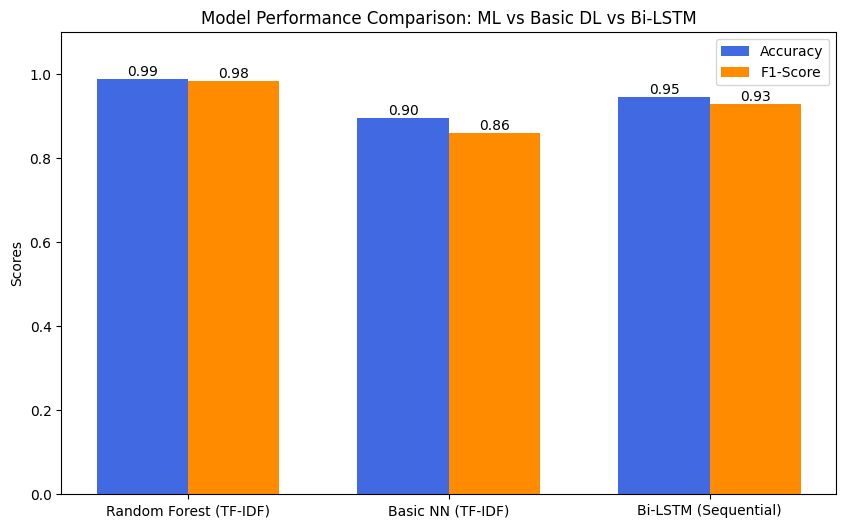

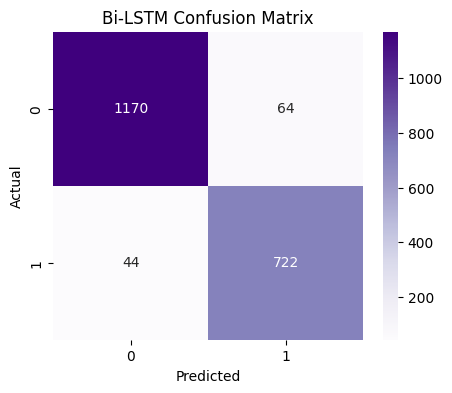

In [10]:
# SECTION 7: Bi-LSTM Implementation & SECTION 8: Critical Comparison
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional
import numpy as np

print("--- SECTION 7: Preparing Sequential Data for Bi-LSTM ---")
# 1. Tokenize the text (keep word order)
max_words = 5000  # Vocabulary size
max_len = 100     # Max sequence length (number of words per abstract)

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['cleaned_text'])

# Convert texts to sequences of numbers and pad them so they are all the same length
X_sequences = tokenizer.texts_to_sequences(df['cleaned_text'])
X_padded = pad_sequences(X_sequences, maxlen=max_len)

# Split identically to our previous models to ensure a fair comparison
X_train_seq, X_test_seq, y_train, y_test = train_test_split(X_padded, y, test_size=0.2, random_state=42)

# 2. Build the Bi-LSTM Model
print("\nTraining Bi-LSTM Model... (This takes a bit longer than the basic NN)")
bilstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
    Bidirectional(LSTM(32)), # Reads text forwards and backwards!
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

bilstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train with early stopping
early_stop_lstm = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
bilstm_history = bilstm_model.fit(X_train_seq, y_train, epochs=10, batch_size=32,
                                  validation_split=0.1, callbacks=[early_stop_lstm], verbose=1)

# Get Predictions
bilstm_probs = bilstm_model.predict(X_test_seq)
bilstm_predictions = (bilstm_probs > 0.5).astype(int).flatten()

bilstm_acc = accuracy_score(y_test, bilstm_predictions)
bilstm_f1 = f1_score(y_test, bilstm_predictions)

print(f"\nBi-LSTM Accuracy: {bilstm_acc:.4f}")
print(f"Bi-LSTM F1-Score: {bilstm_f1:.4f}")

# ---------------------------------------------------------
print("\n--- SECTION 8: Critical Comparison of All 3 Models ---")

# Gather metrics (Assuming rf_predictions and dl_predictions are still in memory from the previous cell)
rf_acc = accuracy_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
basic_dl_acc = accuracy_score(y_test, dl_predictions)
basic_dl_f1 = f1_score(y_test, dl_predictions)

# 1. Bar Chart Comparison
labels = ['Random Forest (TF-IDF)', 'Basic NN (TF-IDF)', 'Bi-LSTM (Sequential)']
accuracies = [rf_acc, basic_dl_acc, bilstm_acc]
f1_scores = [rf_f1, basic_dl_f1, bilstm_f1]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='royalblue')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', color='darkorange')

ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison: ML vs Basic DL vs Bi-LSTM')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim([0, 1.1])
ax.legend()

# Add numbers on top of bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

# 2. Bi-LSTM Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, bilstm_predictions), annot=True, fmt='d', cmap='Purples')
plt.title("Bi-LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
# CELL 8: The Full "COVID-19 Research Paper Analyzer" Inference Function
from spacy import displacy

def full_paper_analyzer(raw_text):
    print("="*60)
    print("🩺 AI RESEARCH PAPER ANALYZER")
    print("="*60)

    # ---------------------------------------------------------
    # 1. CLASSIFICATION (Deep Learning)
    # ---------------------------------------------------------
    cleaned_tokens = clean_with_nltk(raw_text)
    cleaned_text = " ".join(cleaned_tokens)
    vectorized_text = vectorizer.transform([cleaned_text]).toarray()

    prob = dl_model.predict(vectorized_text, verbose=0)[0][0]
    confidence = prob * 100 if prob > 0.5 else (1 - prob) * 100

    print("\n📊 1. CLASSIFICATION RESULT:")
    if prob > 0.5:
        print(f"   ➤ Category: Treatment & Clinical Trials")
    else:
        print(f"   ➤ Category: Public Health / General Virology / Other")
    print(f"   ➤ Confidence: {confidence:.2f}%\n")

    # ---------------------------------------------------------
    # 2. MEDICAL ENTITY EXTRACTION (spaCy)
    # ---------------------------------------------------------
    print("🧬 2. ENTITIES FOUND IN TEXT:")
    doc = nlp(raw_text)
    # Extract entities related to science/medicine (e.g., ORG, PRODUCT, DISEASE if using scientific spacy)
    entities = [ent.text for ent in doc.ents if ent.label_ in ['ORG', 'PRODUCT', 'PERSON', 'LOC', 'DATE']]
    if entities:
        print(f"   ➤ {', '.join(set(entities))}")
    else:
        print("   ➤ No major named entities detected.")

    # Show the visual highlighting directly in Colab
    print("\n   [Visual Entity Highlighting]:")
    displacy.render(doc, style='ent', jupyter=True)

    # ---------------------------------------------------------
    # 3. SEMANTIC SUGGESTIONS (Gensim Word2Vec)
    # ---------------------------------------------------------
    print("\n🔍 3. RELATED RESEARCH KEYWORDS (Based on your text):")
    # Find up to 3 words from the abstract that are in our Word2Vec vocabulary
    valid_words = [word for word in cleaned_tokens if word in w2v_model.wv]

    if valid_words:
        # Take the most frequent valid word in the text to find related terms
        from collections import Counter
        top_word = Counter(valid_words).most_common(1)[0][0]

        print(f"   Because this paper mentions '{top_word}', you might also research:")
        similar_words = w2v_model.wv.most_similar(top_word, topn=3)
        for word, score in similar_words:
            print(f"   ➤ {word} (Similarity: {score:.2f})")
    else:
        print("   ➤ Not enough known vocabulary to suggest related terms.")

    print("="*60 + "\n")

# ==========================================
# Test the Full Analyzer
# ==========================================
test_abstract = """
A new study conducted by the World Health Organization (WHO) evaluated the efficacy
of Remdesivir in treating severe acute respiratory syndrome coronavirus 2 (SARS-CoV-2).
The clinical trial showed that patients recovered 30% faster when the drug was administered
early. However, vaccine distribution remains the primary strategy for public health.
"""
full_paper_analyzer(test_abstract)

🩺 AI RESEARCH PAPER ANALYZER

📊 1. CLASSIFICATION RESULT:
   ➤ Category: Treatment & Clinical Trials
   ➤ Confidence: 100.00%

🧬 2. ENTITIES FOUND IN TEXT:
   ➤ the World Health Organization (WHO, Remdesivir

   [Visual Entity Highlighting]:



🔍 3. RELATED RESEARCH KEYWORDS (Based on your text):
   Because this paper mentions 'health', you might also research:
   ➤ private (Similarity: 0.66)
   ➤ healthcare (Similarity: 0.64)
   ➤ general (Similarity: 0.62)



In [12]:
# CELL 8: COVID-19 Research Paper Analyzer (Web App Inference)
from spacy import displacy
from collections import Counter

def analyze_research_paper(raw_text):
    print("="*70)
    print("🦠 COVID-19 RESEARCH PAPER ANALYZER 🦠")
    print("="*70)

    # ---------------------------------------------------------
    # 1. TEXT CLEANING & VECTORIZATION
    # ---------------------------------------------------------
    cleaned_tokens = clean_with_nltk(raw_text)
    cleaned_text = " ".join(cleaned_tokens)

    # Use our TF-IDF vectorizer
    vectorized_text = vectorizer.transform([cleaned_text]).toarray()

    # ---------------------------------------------------------
    # 2. AI CLASSIFICATION (Using Best Model: Random Forest)
    # ---------------------------------------------------------
    prediction = rf_model.predict(vectorized_text)[0]
    # Get the confidence percentage
    probabilities = rf_model.predict_proba(vectorized_text)[0]
    confidence = max(probabilities) * 100

    print("\n📊 1. AI CLASSIFICATION RESULT:")
    if prediction == 1:
        print(f"   ➤ Category: 🩺 Treatment & Clinical Trials")
    else:
        print(f"   ➤ Category: 🔬 Public Health / General Virology / Other")
    print(f"   ➤ Confidence: {confidence:.2f}%\n")

    # ---------------------------------------------------------
    # 3. MEDICAL ENTITY HIGHLIGHTING (spaCy)
    # ---------------------------------------------------------
    print("🧬 2. KEY ENTITIES DETECTED:")
    doc = nlp(raw_text)

    # Extract important entities
    entities = [ent.text for ent in doc.ents if ent.label_ in ['ORG', 'PRODUCT', 'PERSON', 'LOC', 'DATE', 'GPE']]
    if entities:
        print(f"   ➤ {', '.join(set(entities))}")
    else:
        print("   ➤ No major named entities detected.")

    # Show the visual highlighting directly in the notebook (Just like a web app UI!)
    print("\n   [Visual Abstract Highlighting]:")
    displacy.render(doc, style='ent', jupyter=True)

    # ---------------------------------------------------------
    # 4. SEMANTIC RESEARCH SUGGESTIONS (Word2Vec)
    # ---------------------------------------------------------
    print("\n🔍 3. AI RESEARCH SUGGESTIONS:")
    # Find words from the abstract that exist in our Word2Vec vocabulary
    valid_words = [word for word in cleaned_tokens if word in w2v_model.wv]

    if valid_words:
        # Get the most common significant word from the abstract
        top_word = Counter(valid_words).most_common(1)[0][0]

        print(f"   Because this paper focuses heavily on '{top_word}', you should also research:")
        # Ask Gensim for the top 4 most similar concepts across all 10,000 papers
        similar_words = w2v_model.wv.most_similar(top_word, topn=4)
        for word, score in similar_words:
            print(f"   ➤ {word.capitalize()} (Similarity Match: {score*100:.1f}%)")
    else:
        print("   ➤ Not enough known vocabulary to suggest related terms.")

    print("\n" + "="*70 + "\n")


# ==========================================
# 🧪 TEST YOUR NEW WEB APP FUNCTION!
# ==========================================

print("Testing the Analyzer with a brand new abstract...")

test_abstract = """
A new phase 3 clinical trial conducted by Pfizer in New York evaluated the efficacy
of a novel mRNA vaccine against the SARS-CoV-2 virus. Over 5000 patients were monitored
over 6 months. The treatment significantly reduced hospitalization rates and severe pneumonia.
However, public health officials still recommend wearing masks in crowded indoor locations.
"""

analyze_research_paper(test_abstract)

Testing the Analyzer with a brand new abstract...
🦠 COVID-19 RESEARCH PAPER ANALYZER 🦠

📊 1. AI CLASSIFICATION RESULT:
   ➤ Category: 🩺 Treatment & Clinical Trials
   ➤ Confidence: 96.00%

🧬 2. KEY ENTITIES DETECTED:
   ➤ New York, Pfizer, 6 months

   [Visual Abstract Highlighting]:



🔍 3. AI RESEARCH SUGGESTIONS:
   Because this paper focuses heavily on 'new', you should also research:
   ➤ Novel (Similarity Match: 70.0%)
   ➤ Track (Similarity Match: 65.5%)
   ➤ Quickly (Similarity Match: 64.8%)
   ➤ Rapidly (Similarity Match: 62.7%)




In [13]:
# CELL 9: Export Models for Web Deployment
import joblib
from google.colab import files

print("Saving models...")

# 1. Save the TF-IDF Vectorizer
joblib.dump(vectorizer, 'tfidf_vectorizer.joblib')

# 2. Save the Random Forest Model
joblib.dump(rf_model, 'rf_model.joblib')

# 3. Save the Gensim Word2Vec Model
w2v_model.save('word2vec_model.gensim')

print("Models saved successfully!")

# Download them to your local computer
print("Downloading to your computer...")
files.download('tfidf_vectorizer.joblib')
files.download('rf_model.joblib')
files.download('word2vec_model.gensim')

Saving models...
Models saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>